# Phase 2 — Algorithm Benchmark

Benchmarks the final algorithm comparison set against baselines.
Results are saved to `results/tables/` and consumed by `report.ipynb`.

For algorithm derivations see `algorithm_design.ipynb`.

---
## How to Use This Notebook

**All you need to change is the `RUN_MODE` variable in the Configuration cell (Section 2).**
Everything else — which cache file is loaded, analysis depth, section titles — adapts automatically.

| Mode | Cache file | Reps | When to use |
|---|---|---|---|
| `"quick"` | `benchmark_1rep.csv` | 1 | Development, checkpoint, previewing results |
| `"full"` | `benchmark_5rep.csv` | 5 | Final submission |
| `"custom"` | any file in `results/tables/` | — | Inspecting a specific backup or partial run |

**For the teachers:** to reproduce the submitted results, set `RUN_MODE = "full"` and run all cells.
`benchmark_5rep.csv` is included in the submission — the benchmark loop will be skipped and results
will load directly.

---

### Visualising results before the full run

You do not need to wait for the 5-repetition run to get meaningful results.

Setting `RUN_MODE = "quick"` loads (or produces) the 1-repetition results and runs the **same
analysis sections** as full mode — summary table, boxplots, scatter vs KNNOptK, IR-quartile
breakdown, statistical tests, and bootstrap CI. The analysis code is identical in both modes;
only the framing text adapts.

The key tool in quick mode is **Section 7 — Bootstrap Confidence Intervals**. With 1 repetition
(10 fold-results per algorithm per dataset), there is sampling noise in the per-dataset means.
The bootstrap CI quantifies that noise: it shows a 95% confidence interval around each
algorithm's mean G-mean, computed by resampling the 40 dataset-level means with replacement 2000
times. These intervals are a *prediction* of where the true mean will land once the 5-repetition
run is complete — if two algorithms have non-overlapping intervals in quick mode, they are very
likely to remain separated in the full run.

In practice the 1-repetition results in this notebook correspond to the analysis already present
in `analysis.ipynb`, so the bootstrap CI you see here is the same prediction that guided our
decision to proceed to the 5-repetition run. If you load `benchmark_raw.csv` as the custom file
you can reproduce that exact analysis:

```
RUN_MODE    = "custom"
CUSTOM_FILE = "benchmark_raw.csv"
```

---
## 1. Imports

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import StratifiedKFold

from src.utils.config import load_config, get_project_root
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms import KNNOptK, KNNFairRank, KNNFairRankMagnitude, KNNFairRankCV, KNNClassifierFast
from src.evaluation.metrics import compute_all_metrics
from src.evaluation.statistical_tests import friedman_test, pairwise_wilcoxon, average_ranks

cfg = load_config()
SEED = cfg["random_seed"]

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = get_project_root() / cfg["paths"]["results_figures"]
TAB_DIR = get_project_root() / cfg["paths"]["results_tables"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

---
## 2. Configuration

**Change only this cell.**

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# MODE TOGGLE
# ─────────────────────────────────────────────────────────────────────────────
RUN_MODE    = "quick"             # "quick" | "full" | "custom"
CUSTOM_FILE = "benchmark_raw.csv" # only used when RUN_MODE = "custom"
# ─────────────────────────────────────────────────────────────────────────────

_N_REPS  = {"quick": 1, "full": 5}
_CACHES  = {
    "quick":  TAB_DIR / "benchmark_1rep.csv",
    "full":   TAB_DIR / "benchmark_5rep.csv",
    "custom": TAB_DIR / CUSTOM_FILE,
}

N_REPS = _N_REPS.get(RUN_MODE, None)
CACHE  = _CACHES[RUN_MODE]

display(Markdown(f"""**Active mode:** `{RUN_MODE}`  
**Cache file:** `{CACHE.name}`  
**Repetitions:** {N_REPS if N_REPS else "N/A (loading existing file)"}  
**Cache exists:** {CACHE.exists()}
"""))

**Active mode:** `quick`  
**Cache file:** `benchmark_1rep.csv`  
**Repetitions:** 1  
**Cache exists:** True


---
## 3. Algorithm Selection

### 3.1 Full algorithm landscape

During development we tested 14 algorithms across two research directions.
Results below are from the 1-repetition run in `benchmark_raw.csv` (G-mean, averaged over all datasets).

| Algorithm | G-mean | Direction | Status |
|---|---|---|---|
| `KNNFairRankCV` | 0.793 | Fair-rank correction | ✅ final set |
| `KNNFairRank` | 0.787 | Fair-rank correction | ✅ final set |
| `KNNFairRankMagnitude` | 0.784 | Fair-rank correction | ✅ final set |
| `KNNWeighted` | 0.766 | Distance weighting | excluded — not our proposal |
| `SMOTE+KNN` | 0.736 | Data augmentation | ✅ final set (industry baseline) |
| `SMOTE+KNNOptK` | 0.734 | Data augmentation | ❌ too slow for 5-rep run |
| `KNNAdaptiveTopo` | 0.618 | Local-k adaptation | ✅ final set (represents k-adaptation direction) |
| `KNNOptK` | 0.600 | CV k selection | ✅ final set (Phase 1 baseline) |
| `KNNAdaptiveDualAnchor` | 0.556 | Local-k adaptation | ❌ underperforms KNNOptK |
| `KNNBaseline` | 0.539 | — | ❌ trivial baseline, not needed |
| `KNNAdaptiveEntropy` | 0.463 | Local-k adaptation | ❌ poor performance |
| `KNNAdaptiveEigen` | 0.404 | Local-k adaptation | ❌ poor performance |
| `DANN` | 0.380 | Distance weighting | ❌ poor performance |
| `DANNAdaptive` | 0.333 | Distance weighting | ❌ poor performance |

### 3.2 Why these exclusions?

**`SMOTE+KNNOptK`** — combining SMOTE resampling with inner CV k-selection roughly doubles compute time per fold. The 1-rep run already left 6 datasets incomplete (46/49). Its G-mean (0.734) is also marginally *below* vanilla `SMOTE+KNN` (0.736), so there is no performance justification for the extra cost. The full analysis is in `analysis.ipynb`.

**`KNNAdaptiveEntropy`, `KNNAdaptiveEigen`, `DANN`, `DANNAdaptive`** — all underperform `KNNOptK` (0.600) by a wide margin (0.333–0.463). Including them in the 5-repetition run would add substantial compute time with no prospect of a competitive result. Their full results are preserved in `benchmark_raw.csv` (1-rep) and discussed in `analysis.ipynb`.

**`KNNAdaptiveDualAnchor`** — underperforms `KNNOptK` (0.556 vs 0.600) and does not represent a distinct research direction worth carrying to the final comparison.

### 3.3 Why keep `KNNAdaptiveTopo`?

`KNNAdaptiveTopo` (G-mean 0.618) is the best representative of the local-k adaptation direction — the first research hypothesis we pursued before arriving at the fair-rank insight. Including it in the final comparison tells the full story: topology-based local adaptation meaningfully improves over `KNNOptK`, but is still substantially below the fair-rank family. This contrast directly motivates the structural argument in `phase1_baseline.ipynb §3.2` — that the problem is not k-selection but the rank comparison itself.

In [3]:
datasets = load_all_datasets()
print(f'Loaded {len(datasets)} datasets.')

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 49 datasets.


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [4]:
from imblearn.over_sampling import SMOTE
from src.evaluation.benchmarking import run_benchmark
from src.algorithms import KNNAdaptiveTopo

# SMOTE+KNN: SMOTE resampling + fast fixed-k KNN (k=5)
# Uses KNNClassifierFast, NOT KNNOptK — keeping it fast is the whole point
class SMOTEKNNWrapper:
    def __init__(self):
        self._smote = SMOTE(random_state=SEED)
        self._clf   = KNNClassifierFast(k=5)

    def fit(self, X, y):
        X_res, y_res = self._smote.fit_resample(X, y)
        self._clf.fit(X_res, y_res)
        return self

    def predict(self, X):
        return self._clf.predict(X)

# run_benchmark expects classes, not instances
ALGORITHMS = {
    "KNNOptK":              KNNOptK,           # Phase 1 baseline
    "SMOTE+KNN":            SMOTEKNNWrapper,   # Industry baseline (fast)
    "KNNAdaptiveTopo":      KNNAdaptiveTopo,   # Best local-k adaptation direction
    "KNNFairRank":          KNNFairRank,       # Our proposal — theoretical baseline
    "KNNFairRankMagnitude": KNNFairRankMagnitude,  # Mod B
    "KNNFairRankCV":        KNNFairRankCV,     # Mod C — headline variant
}

print("Final comparison set:")
for name in ALGORITHMS:
    print(f"  {name}")

Final comparison set:
  KNNOptK
  SMOTE+KNN
  KNNAdaptiveTopo
  KNNFairRank
  KNNFairRankMagnitude
  KNNFairRankCV


---
## 4. Benchmark Run

10-fold stratified CV, repeated `N_REPS` times. If the cache for the current mode already
exists the run cell prints a confirmation and skips all computation.

In [5]:
# ── Custom mode: always load, never run ──────────────────────────────────────
if RUN_MODE == "custom":
    if not CACHE.exists():
        available = "\n".join(f"  {p.name}" for p in sorted(TAB_DIR.glob("*.csv")))
        raise FileNotFoundError(
            f"Custom file not found: {CACHE.name}\n"
            f"Available files in results/tables/:\n{available}")
    bench_df = pd.read_csv(CACHE)
    display(Markdown(f"**Custom load:** `{CACHE.name}` — {len(bench_df):,} rows, "
                     f"{bench_df['repeat'].nunique()} repeat(s), "
                     f"{bench_df['dataset'].nunique()} datasets, "
                     f"{bench_df['algorithm'].nunique()} algorithms."))

# ── Quick / full: delegate entirely to run_benchmark ─────────────────────────
else:
    bench_df = run_benchmark(
        estimators=ALGORITHMS,
        datasets=datasets,
        output_path=CACHE,
        n_jobs=1,
        n_repetitions=N_REPS,
    )
    display(Markdown(f"**{'Loaded from cache' if CACHE.exists() else 'Run complete'}:** "
                     f"`{CACHE.name}` — {len(bench_df):,} rows, "
                     f"{bench_df['repeat'].nunique()} repeat(s), "
                     f"{bench_df['dataset'].nunique()} datasets, "
                     f"{bench_df['algorithm'].nunique()} algorithms."))

  Resuming: 294 (dataset, algorithm) pairs already done (49 datasets fully complete, 0 partially/not started).
  All combinations already complete — loading from cache.


**Loaded from cache:** `benchmark_1rep.csv` — 6,830 rows, 1 repeat(s), 49 datasets, 14 algorithms.

---
## 5. Post-Benchmark Data Preparation

In [6]:
# Filter degenerate datasets (fewer than 2*cv_folds minority samples → unreliable CV)
min_minority = 2 * cfg["evaluation"]["cv_folds"]
valid_datasets = [
    ds.name for ds in datasets
    if int(binarise_labels(ds.y).sum()) >= min_minority
]
removed = bench_df[~bench_df["dataset"].isin(valid_datasets)]["dataset"].unique()
bench_df = bench_df[bench_df["dataset"].isin(valid_datasets)].reset_index(drop=True)
print(f"Removed {len(removed)} degenerate datasets: {list(removed)}")
print(f"Remaining: {bench_df['dataset'].nunique()} datasets, {bench_df['algorithm'].nunique()} algorithms")

# Full mode: restrict to the final comparison set only
# Quick / custom: analyse all algorithms present in the file
if RUN_MODE == "full":
    FINAL_ALGS = list(ALGORITHMS.keys())
    bench_df = bench_df[bench_df["algorithm"].isin(FINAL_ALGS)].reset_index(drop=True)
    print(f"Full mode — restricted to final algorithm set: {sorted(bench_df['algorithm'].unique().tolist())}")
else:
    print(f"{'Quick' if RUN_MODE == 'quick' else 'Custom'} mode — all algorithms in file: {sorted(bench_df['algorithm'].unique().tolist())}")

# ── Detect actual rep count from data and derive mode metadata ────────────────
N_ACTUAL_REPS = bench_df["repeat"].nunique()

if RUN_MODE == "custom":
    # Treat as final if the file has 5+ reps; preliminary otherwise
    IS_FINAL   = N_ACTUAL_REPS >= 5
    _desc      = f"final ({N_ACTUAL_REPS} reps)" if IS_FINAL else f"preliminary ({N_ACTUAL_REPS} rep(s))"
    MODE_LABEL = f"Custom: {CACHE.name} — {_desc}"
    FILE_SUFFIX = CACHE.stem   # e.g. "benchmark_raw" → outputs named *_benchmark_raw.*
else:
    IS_FINAL    = (RUN_MODE == "full")
    MODE_LABEL  = (f"Final results — {N_ACTUAL_REPS} reps"
                   if IS_FINAL else
                   f"Preliminary — predicting full run ({N_ACTUAL_REPS} rep)")
    FILE_SUFFIX = f"{N_ACTUAL_REPS}rep"   # "1rep" or "5rep" — self-documenting

display(Markdown(
    f"**Mode:** `{RUN_MODE}` | **Reps in data:** {N_ACTUAL_REPS} | "
    f"**Treated as:** {'final' if IS_FINAL else 'preliminary'} | "
    f"**Output suffix:** `_{FILE_SUFFIX}`  \n"
    f"**Label:** {MODE_LABEL}"
))

Removed 9 degenerate datasets: ['dataset_1013_analcatdata_challenger', 'dataset_1045_kc1-top5', 'dataset_1059_ar1', 'dataset_1064_ar6', 'dataset_450_analcatdata_lawsuit', 'dataset_865_analcatdata_neavote', 'dataset_950_arsenic-female-lung', 'dataset_951_arsenic-male-lung', 'dataset_875_analcatdata_chlamydia']
Remaining: 40 datasets, 14 algorithms
Quick mode — all algorithms in file: ['DANN', 'DANNAdaptive_entropy', 'KNNAdaptiveDualAnchor', 'KNNAdaptiveEigen', 'KNNAdaptiveEntropy', 'KNNAdaptiveTopo', 'KNNBaseline', 'KNNFairRank', 'KNNFairRankCV', 'KNNFairRankMagnitude', 'KNNOptK', 'KNNWeighted', 'SMOTE+KNN', 'SMOTE+KNNOptK']


**Mode:** `quick` | **Reps in data:** 1 | **Treated as:** preliminary | **Output suffix:** `_1rep`  
**Label:** Preliminary — predicting full run (1 rep)

---
## 5.0 Metrics for Imbalanced Binary Classification — Interpretation Guide

Before reading the benchmark tables, it is important to understand *what each metric measures* and *why metric choice matters under class imbalance*. The four metrics we track below each reward different things, and the "best" algorithm can change depending on which metric you privilege.

### 5.0.1 The Failure of Accuracy

Plain accuracy is unusable here. With 99% majority / 1% minority (common in our dataset collection), a trivial classifier that always predicts majority scores 99% accuracy — yet has zero diagnostic value. Every metric below is designed to not be fooled by this.

### 5.0.2 Building Blocks: The Confusion Matrix

For binary classification with the minority class as the "positive" class:

|  | Predicted minority | Predicted majority |
|---|---|---|
| **Actual minority** | TP (true positive) | FN (false negative) |
| **Actual majority** | FP (false positive) | TN (true negative) |

From these we derive the two class-specific recall rates:

$$\text{TPR} = \frac{TP}{TP + FN}, \qquad \text{TNR} = \frac{TN}{TN + FP}$$

### 5.0.3 F1 Score

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{TPR}}{\text{Precision} + \text{TPR}}$$

Harmonic mean of minority-class precision and recall. Does not use TN. Standard in the broader ML literature but **asymmetric** and sensitive to minority-class precision — which systematically penalises algorithms that trade precision for balanced recall.

### 5.0.4 G-mean

$$\text{G-mean} = \sqrt{\text{TPR} \cdot \text{TNR}}$$

Geometric mean of both class recalls. If either recall is zero, G-mean = 0 — a classifier cannot compensate for catastrophically missing one class by over-performing on the other. **Primary metric for this project**: introduced specifically for imbalanced classification (Kubat & Matwin 1997), symmetric, and punishes asymmetry.

### 5.0.5 Balanced Accuracy

$$\text{BA} = \frac{\text{TPR} + \text{TNR}}{2}$$

Arithmetic mean of both class recalls. Similar to G-mean but does not punish asymmetry. Close second to G-mean for interpretability.

### 5.0.6 ROC AUC

Probability that a randomly chosen minority sample is ranked higher than a randomly chosen majority sample. Threshold-independent — evaluates ranking quality, not hard-label performance. Useful to diagnose whether a classifier with low F1/BA has good underlying discrimination that a better threshold could unlock.

### 5.0.7 Which Metric Is Primary?

**G-mean** meets all requirements: not fooled by always-predict-majority, symmetric, reflects hard-label quality, and is standard in the imbalance literature. Results are ordered by G-mean throughout; F1 is reported for comparability with the broader ML literature.

---
## 5.1 Overall Mean Metrics per Algorithm

In [7]:
from src.evaluation.statistical_tests import friedman_test, pairwise_wilcoxon, average_ranks, critical_difference

METRICS = ["f1", "balanced_accuracy", "geometric_mean", "roc_auc"]

summary_table = (
    bench_df
    .groupby("algorithm")[METRICS]
    .mean()
    .round(4)
    .sort_values("geometric_mean", ascending=False)
)
summary_table.to_csv(TAB_DIR / f"benchmark_summary_{FILE_SUFFIX}.csv")

# Delta vs KNNOptK
optk_means = summary_table.loc["KNNOptK"]
delta_table = (summary_table - optk_means).round(4)
delta_table.columns = [f"Δ_{c}" for c in delta_table.columns]

display_table = pd.concat([summary_table, delta_table], axis=1)
print(f"Mean metrics — {MODE_LABEL}")
print("(Δ columns = difference vs KNNOptK)")
print(display_table.to_string())

print("\nPer-metric leaders:")
for m in METRICS:
    leader = summary_table[m].idxmax()
    print(f"  {m:<22}  →  {leader:<28}  ({summary_table.loc[leader, m]:.4f})")

ALG_ORDER = summary_table.index.tolist()
display_table

Mean metrics — Preliminary — predicting full run (1 rep)
(Δ columns = difference vs KNNOptK)
                           f1  balanced_accuracy  geometric_mean  roc_auc    Δ_f1  Δ_balanced_accuracy  Δ_geometric_mean  Δ_roc_auc
algorithm                                                                                                                          
KNNFairRankCV          0.5912             0.8408          0.8272   0.8674  0.0399               0.0881            0.1922     0.0873
KNNFairRank            0.5367             0.8316          0.8202   0.8639 -0.0146               0.0789            0.1852     0.0838
KNNFairRankMagnitude   0.5316             0.8272          0.8147   0.8798 -0.0197               0.0745            0.1797     0.0997
KNNWeighted            0.5844             0.8209          0.7983   0.8431  0.0331               0.0682            0.1633     0.0630
SMOTE+KNNOptK          0.6352             0.8181          0.7850   0.8216  0.0839               0.0654            0

,f1,balanced_accuracy,geometric_mean,roc_auc,Δ_f1,Δ_balanced_accuracy,Δ_geometric_mean,Δ_roc_auc
algorithm,,,,,,,,
KNNFairRankCV,0.5912,0.8408,0.8272,0.8674,0.0399,0.0881,0.1922,0.0873
KNNFairRank,0.5367,0.8316,0.8202,0.8639,-0.0146,0.0789,0.1852,0.0838
KNNFairRankMagnitude,0.5316,0.8272,0.8147,0.8798,-0.0197,0.0745,0.1797,0.0997
KNNWeighted,0.5844,0.8209,0.7983,0.8431,0.0331,0.0682,0.1633,0.0630
SMOTE+KNNOptK,0.6352,0.8181,0.7850,0.8216,0.0839,0.0654,0.1500,0.0415
SMOTE+KNN,0.5527,0.7922,0.7705,0.8206,0.0014,0.0395,0.1355,0.0405
KNNAdaptiveTopo,0.5615,0.7555,0.6623,0.7557,0.0102,0.0028,0.0273,-0.0244
KNNOptK,0.5513,0.7527,0.6350,0.7801,0.0000,0.0000,0.0000,0.0000
KNNAdaptiveDualAnchor,0.5320,0.7384,0.5887,0.8620,-0.0193,-0.0143,-0.0463,0.0819


### 5.2 Boxplots: Per-Fold Distribution

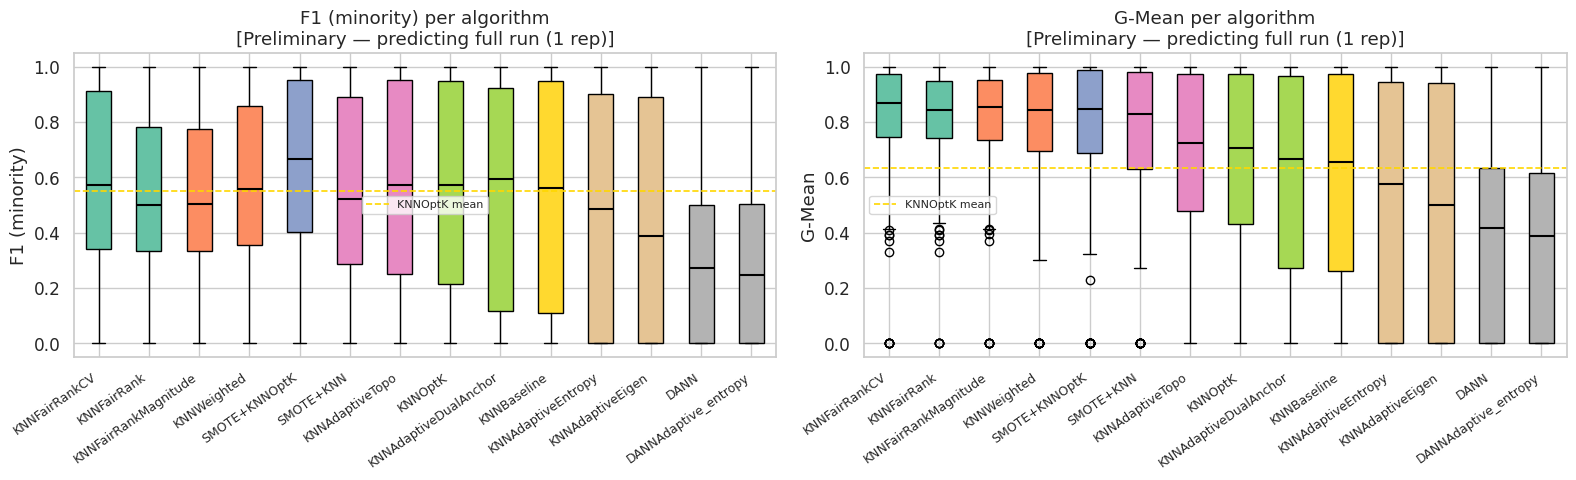

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    data_plot = [bench_df[bench_df["algorithm"] == alg][metric].dropna().values for alg in ALG_ORDER]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=1.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(ALG_ORDER)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_xticks(range(1, len(ALG_ORDER) + 1))
    ax.set_xticklabels(ALG_ORDER, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(f"{label} per algorithm\n[{MODE_LABEL}]")
    ax.axhline(summary_table.loc["KNNOptK", metric], color="gold",
               linestyle="--", linewidth=1.2, label="KNNOptK mean")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / f"benchmark_boxplots_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Per-Dataset Scatter vs KNNOptK

Each point is one dataset. Above the diagonal = improvement over KNNOptK.

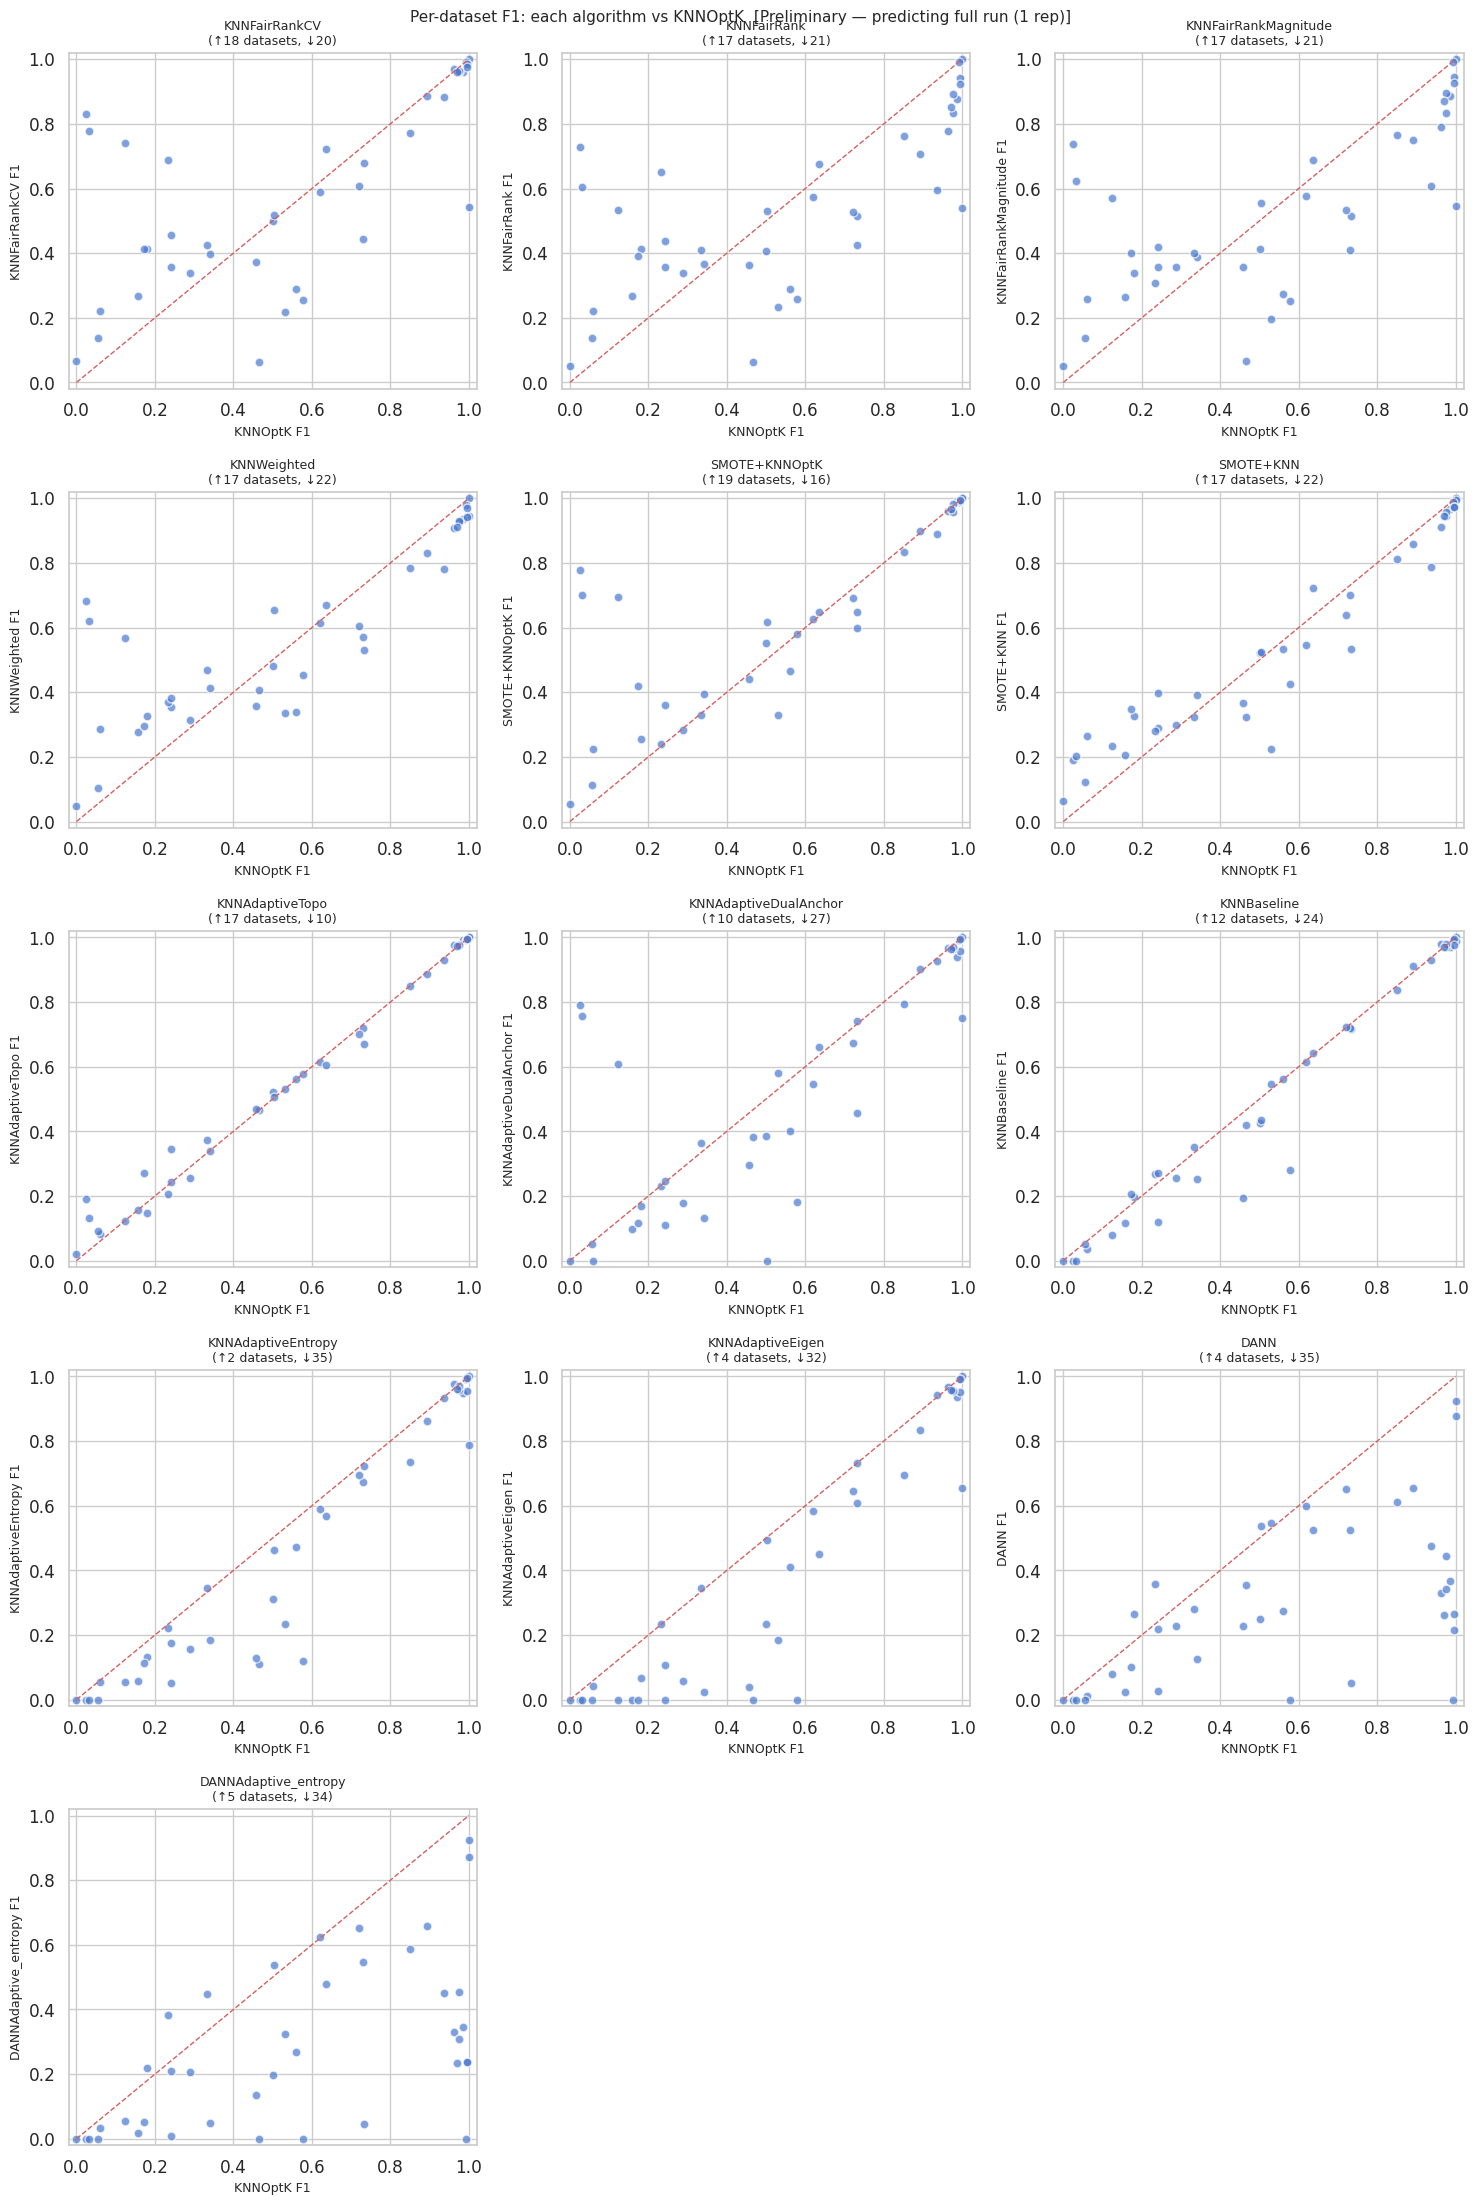

In [9]:
per_ds_alg = (
    bench_df
    .groupby(["dataset", "algorithm"])["f1"]
    .mean()
    .unstack("algorithm")
)

competitors = [a for a in ALG_ORDER if a != "KNNOptK"]
n_cols = 3
n_rows = int(np.ceil(len(competitors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.ravel()

for ax, alg in zip(axes, competitors):
    x = per_ds_alg["KNNOptK"]
    y_alg = per_ds_alg[alg]
    wins = (y_alg > x).sum()
    losses = (y_alg < x).sum()
    ax.scatter(x, y_alg, alpha=0.7, edgecolors="white", s=40)
    ax.plot([0, 1], [0, 1], "r--", linewidth=1)
    ax.set_xlabel("KNNOptK F1", fontsize=9)
    ax.set_ylabel(f"{alg} F1", fontsize=9)
    ax.set_title(f"{alg}\n(↑{wins} datasets, ↓{losses})", fontsize=9)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

for ax in axes[len(competitors):]:
    ax.set_visible(False)

fig.suptitle(f"Per-dataset F1: each algorithm vs KNNOptK  [{MODE_LABEL}]", fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / f"benchmark_scatter_vs_optk_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4 Performance by Imbalance Severity (IR Quartiles)

/tmp/ipykernel_14618/1328053146.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ir_summary_f1 = (bench_df.groupby(["IR_quartile", "algorithm"])["f1"]
/tmp/ipykernel_14618/1328053146.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ir_summary_gmean = (bench_df.groupby(["IR_quartile", "algorithm"])["geometric_mean"]


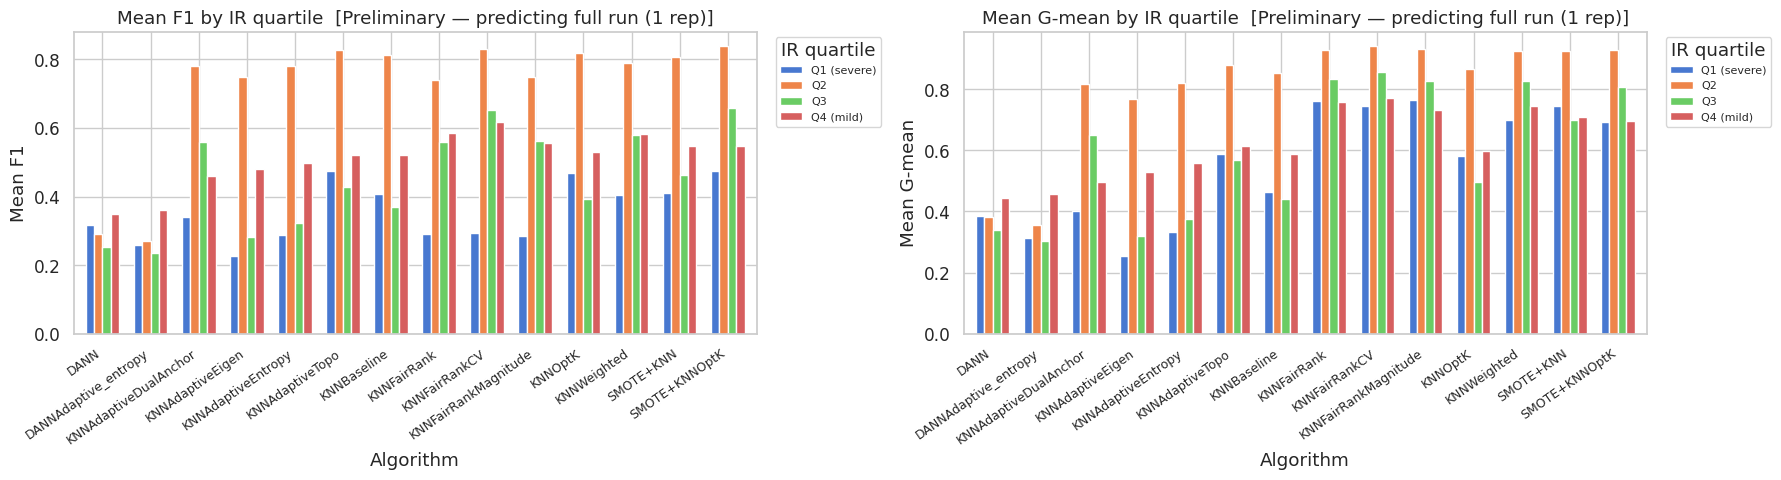

G-mean by IR quartile (primary metric):
algorithm      DANN  DANNAdaptive_entropy  KNNAdaptiveDualAnchor  KNNAdaptiveEigen  KNNAdaptiveEntropy  KNNAdaptiveTopo  KNNBaseline  KNNFairRank  KNNFairRankCV  KNNFairRankMagnitude  KNNOptK  KNNWeighted  SMOTE+KNN  SMOTE+KNNOptK
IR_quartile                                                                                                                                                                                                                           
Q1 (severe)  0.3840                0.3136                 0.3999            0.2546              0.3329           0.5894       0.4636       0.7622         0.7444                0.7639   0.5798       0.6994     0.7437         0.6933
Q2           0.3812                0.3561                 0.8176            0.7670              0.8215           0.8781       0.8523       0.9268         0.9402                0.9325   0.8663       0.9253     0.9257         0.9294
Q3           0.3377                0

In [10]:
bench_df["IR_quartile"] = pd.qcut(bench_df["imbalance_ratio"], q=4,
                                   labels=["Q1 (severe)", "Q2", "Q3", "Q4 (mild)"])

ir_summary_f1 = (bench_df.groupby(["IR_quartile", "algorithm"])["f1"]
                 .mean().unstack("algorithm").round(4))
ir_summary_gmean = (bench_df.groupby(["IR_quartile", "algorithm"])["geometric_mean"]
                    .mean().unstack("algorithm").round(4))

ir_summary_f1.to_csv(TAB_DIR / f"benchmark_by_ir_quartile_{FILE_SUFFIX}.csv")
ir_summary_gmean.to_csv(TAB_DIR / f"benchmark_by_ir_quartile_gmean_{FILE_SUFFIX}.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, tbl, label in zip(axes, [ir_summary_f1, ir_summary_gmean], ["F1", "G-mean"]):
    tbl.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(f"Mean {label} by IR quartile  [{MODE_LABEL}]")
    ax.legend(title="IR quartile", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / f"benchmark_by_ir_quartile_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

print("G-mean by IR quartile (primary metric):")
print(ir_summary_gmean.to_string())

---
## 5.5 Bootstrap Confidence Intervals

In [11]:
if RUN_MODE == "full":
    display(Markdown(
        "**Full run — confirming stability.** "
        "These are the final results. Bootstrap CI shows the uncertainty from the finite dataset pool: "
        "if two algorithms have non-overlapping intervals they are robustly separated across the benchmark."))
else:
    display(Markdown(
        "**Quick / custom run — predicting the full-run result.** "
        "With 1 repetition (10 fold-results per algorithm per dataset) there is sampling noise in the "
        "per-dataset means. Bootstrap CI resamples the dataset-level means to predict where the true mean "
        "will land in the 5-repetition run. Non-overlapping intervals mean the ranking is very likely to "
        "survive the full run."))

**Quick / custom run — predicting the full-run result.** With 1 repetition (10 fold-results per algorithm per dataset) there is sampling noise in the per-dataset means. Bootstrap CI resamples the dataset-level means to predict where the true mean will land in the 5-repetition run. Non-overlapping intervals mean the ranking is very likely to survive the full run.

In [12]:
B_BOOT = 2000
ALPHA_CI = 0.05
rng_ci = np.random.default_rng(SEED)

per_ds_metric = bench_df.groupby(["dataset", "algorithm"])[METRICS].mean()

ci_rows = []
for metric in METRICS:
    pivot = per_ds_metric[metric].unstack("algorithm")
    for alg in pivot.columns:
        vals = pivot[alg].dropna().values
        n = len(vals)
        obs_mean = vals.mean()
        boot_means = np.array([
            rng_ci.choice(vals, size=n, replace=True).mean()
            for _ in range(B_BOOT)
        ])
        lo = np.percentile(boot_means, 100 * ALPHA_CI / 2)
        hi = np.percentile(boot_means, 100 * (1 - ALPHA_CI / 2))
        ci_rows.append({
            "algorithm": alg, "metric": metric,
            "mean": round(obs_mean, 4),
            "ci_lower": round(lo, 4),
            "ci_upper": round(hi, 4),
            "ci_width": round(hi - lo, 4),
            "n_datasets": n,
        })

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(TAB_DIR / f"bootstrap_ci_{FILE_SUFFIX}.csv", index=False)

for metric, label in [("geometric_mean", "G-mean (primary)"), ("f1", "F1")]:
    m_ci = (ci_df[ci_df["metric"] == metric]
            .set_index("algorithm")
            .sort_values("mean", ascending=False))
    n_ds = int(m_ci["n_datasets"].iloc[0])
    print(f"\nBootstrap 95% CI — {label}  (B={B_BOOT}, {n_ds} datasets) [{MODE_LABEL}]")
    print("{:<28} {:>9} {:>22}  {:>8}".format("Algorithm", "Mean", "95% CI", "Width"))
    print("-" * 72)
    for alg, row in m_ci.iterrows():
        ci_str = "[{:.4f}, {:.4f}]".format(row["ci_lower"], row["ci_upper"])
        print("{:<28} {:>9.4f} {:>22}  {:>8.4f}".format(alg, row["mean"], ci_str, row["ci_width"]))


Bootstrap 95% CI — G-mean (primary)  (B=2000, 40 datasets) [Preliminary — predicting full run (1 rep)]
Algorithm                         Mean                 95% CI     Width
------------------------------------------------------------------------
KNNFairRankCV                   0.8272       [0.7822, 0.8763]    0.0940
KNNFairRank                     0.8202       [0.7739, 0.8612]    0.0872
KNNFairRankMagnitude            0.8147       [0.7639, 0.8604]    0.0964
KNNWeighted                     0.7983       [0.7344, 0.8557]    0.1214
SMOTE+KNNOptK                   0.7850       [0.7154, 0.8505]    0.1351
SMOTE+KNN                       0.7705       [0.7089, 0.8333]    0.1244
KNNAdaptiveTopo                 0.6623       [0.5714, 0.7487]    0.1773
KNNOptK                         0.6350       [0.5343, 0.7331]    0.1988
KNNAdaptiveDualAnchor           0.5887       [0.4884, 0.6891]    0.2007
KNNBaseline                     0.5830       [0.4758, 0.6886]    0.2128
KNNAdaptiveEntropy             

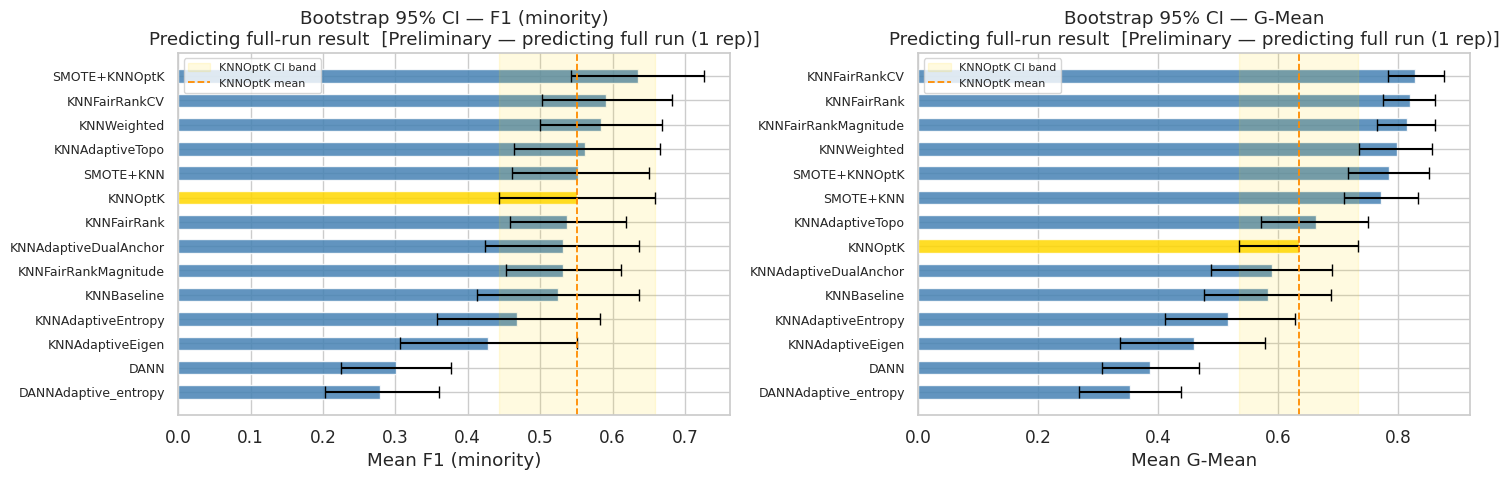

Gold band = KNNOptK 95% CI. Algorithms whose CI does not overlap with the band
are robustly separated from the Phase 1 baseline.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    m_ci = (ci_df[ci_df["metric"] == metric]
            .set_index("algorithm")
            .sort_values("mean", ascending=False))
    algs = m_ci.index.tolist()
    y = np.arange(len(algs))
    colors = ["gold" if a == "KNNOptK" else "steelblue" for a in algs]

    ax.barh(y, m_ci["mean"],
            xerr=[m_ci["mean"] - m_ci["ci_lower"], m_ci["ci_upper"] - m_ci["mean"]],
            height=0.55, capsize=4, color=colors, ecolor="black", alpha=0.85)

    if "KNNOptK" in m_ci.index:
        optk_lo = m_ci.loc["KNNOptK", "ci_lower"]
        optk_hi = m_ci.loc["KNNOptK", "ci_upper"]
        ax.axvspan(optk_lo, optk_hi, alpha=0.12, color="gold", label="KNNOptK CI band")
        ax.axvline(m_ci.loc["KNNOptK", "mean"], color="darkorange",
                   linestyle="--", linewidth=1.3, label="KNNOptK mean")

    ax.set_yticks(y); ax.set_yticklabels(algs, fontsize=9)
    ci_title = "Final results" if IS_FINAL else "Predicting full-run result"
    ax.set(xlabel=f"Mean {label}",
           title=f"Bootstrap 95% CI — {label}\n{ci_title}  [{MODE_LABEL}]")
    ax.invert_yaxis(); ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / f"bootstrap_ci_forest_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gold band = KNNOptK 95% CI. Algorithms whose CI does not overlap with the band")
print("are robustly separated from the Phase 1 baseline.")

---
## 6. Statistical Analysis

Following Demšar (2006):

1. **Friedman test** — global null: all algorithms perform equally.
2. **Pairwise Wilcoxon signed-rank tests with Holm correction** — each algorithm vs three baselines:
   - vs `KNNOptK`: beats a principled k-selection baseline?
   - vs `KNNFairRank`: did Mod B / Mod C improve over the theoretical v3?
   - vs `SMOTE+KNN`: does FairRank close the gap to the industry standard?
3. **Average ranks** — lower = better across datasets.

In [14]:
if not IS_FINAL:
    display(Markdown(
        "> **Preliminary mode:** Friedman and Wilcoxon tests run on 1 repetition "
        "(10 fold-results per dataset per algorithm). Results are indicative — "
        "p-values have lower power than the 5-repetition run. Use for direction, not for significance claims."))

for metric in ["f1", "balanced_accuracy", "geometric_mean"]:
    stat, p = friedman_test(bench_df, metric=metric)
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"Friedman  {metric:<22}  χ²={stat:.3f}  p={p:.4f}  [{sig}]")

> **Preliminary mode:** Friedman and Wilcoxon tests run on 1 repetition (10 fold-results per dataset per algorithm). Results are indicative — p-values have lower power than the 5-repetition run. Use for direction, not for significance claims.

Friedman  f1                      χ²=131.693  p=0.0000  [✓ significant]
Friedman  balanced_accuracy       χ²=182.848  p=0.0000  [✓ significant]
Friedman  geometric_mean          χ²=260.272  p=0.0000  [✓ significant]


In [15]:
def _wilcoxon_report(bench_df, baseline, metric, label, focus=None):
    wilcox = pairwise_wilcoxon(bench_df, baseline=baseline, metric=metric)
    safe_base = baseline.replace("+", "").replace(" ", "_")
    wilcox.to_csv(TAB_DIR / f"wilcoxon_vs_{safe_base}_{metric}_{FILE_SUFFIX}.csv", index=False)

    per_ds = bench_df.groupby(["dataset", "algorithm"])[metric].mean().unstack()

    print(f"\nWilcoxon ({label}) vs {baseline} — Holm corrected:")
    show = wilcox[wilcox["significant"]]
    if focus is not None:
        focus_rows = wilcox[wilcox["algorithm"].isin(focus)]
        show = pd.concat([show, focus_rows]).drop_duplicates(subset=["algorithm"])
        show = show.sort_values("p_raw")
    if len(show) == 0:
        print("  (no significant differences)")
    for _, row in show.iterrows():
        alg = row["algorithm"]
        delta = (per_ds[alg] - per_ds[baseline]).mean()
        direction = "BETTER" if delta > 0 else "WORSE"
        tag = "*" if row["significant"] else " "
        print(f"  {tag} {alg:<28s}  Δmean={delta:+.4f}  {direction}  p_corr={row['p_corrected']:.4f}")
    return wilcox

FAIR_VARIANTS = ["KNNFairRank", "KNNFairRankMagnitude", "KNNFairRankCV"]

for metric, label in [("geometric_mean", "G-mean"), ("f1", "F1"), ("roc_auc", "ROC AUC")]:
    print("=" * 78)
    print(f"METRIC: {label}  [{MODE_LABEL}]")
    print("=" * 78)
    _wilcoxon_report(bench_df, baseline="KNNOptK",     metric=metric, label=label, focus=FAIR_VARIANTS)
    _wilcoxon_report(bench_df, baseline="KNNFairRank", metric=metric, label=label,
                     focus=[v for v in FAIR_VARIANTS if v != "KNNFairRank"])
    _wilcoxon_report(bench_df, baseline="SMOTE+KNN",   metric=metric, label=label, focus=FAIR_VARIANTS)

METRIC: G-mean  [Preliminary — predicting full run (1 rep)]

Wilcoxon (G-mean) vs KNNOptK — Holm corrected:
  * KNNAdaptiveEigen              Δmean=-0.1749  WORSE  p_corr=0.0000
  * KNNAdaptiveEntropy            Δmean=-0.1184  WORSE  p_corr=0.0000
  * SMOTE+KNNOptK                 Δmean=+0.1391  BETTER  p_corr=0.0001
  * DANN                          Δmean=-0.2496  WORSE  p_corr=0.0001
  * SMOTE+KNN                     Δmean=+0.1356  BETTER  p_corr=0.0001
  * DANNAdaptive_entropy          Δmean=-0.2813  WORSE  p_corr=0.0001
  * KNNWeighted                   Δmean=+0.1633  BETTER  p_corr=0.0001
  * KNNFairRankCV                 Δmean=+0.1923  BETTER  p_corr=0.0002
  * KNNFairRankMagnitude          Δmean=+0.1797  BETTER  p_corr=0.0005
  * KNNFairRank                   Δmean=+0.1852  BETTER  p_corr=0.0006
  * KNNBaseline                   Δmean=-0.0519  WORSE  p_corr=0.0020
  * KNNAdaptiveTopo               Δmean=+0.0274  BETTER  p_corr=0.0022
  * KNNAdaptiveDualAnchor         Δmean=-0.04


Average ranks (G-mean (primary)) [Preliminary — predicting full run (1 rep)]:
algorithm
KNNFairRankCV             3.688
KNNWeighted               4.338
SMOTE+KNN                 4.475
KNNFairRankMagnitude      4.588
SMOTE+KNNOptK             4.662
KNNFairRank               5.288
KNNAdaptiveTopo           6.588
KNNOptK                   7.262
KNNBaseline               8.300
KNNAdaptiveDualAnchor     9.625
KNNAdaptiveEntropy       10.375
DANN                     11.525
KNNAdaptiveEigen         11.788
DANNAdaptive_entropy     11.800
Critical difference (Nemenyi α=0.05): 2.403

Average ranks (F1 (secondary)) [Preliminary — predicting full run (1 rep)]:
algorithm
SMOTE+KNNOptK             4.797
KNNAdaptiveTopo           5.288
KNNFairRankCV             5.312
KNNOptK                   5.462
KNNBaseline               6.200
KNNWeighted               6.438
SMOTE+KNN                 6.450
KNNFairRankMagnitude      7.512
KNNAdaptiveDualAnchor     7.550
KNNFairRank               7.788
KNNAdaptiveE

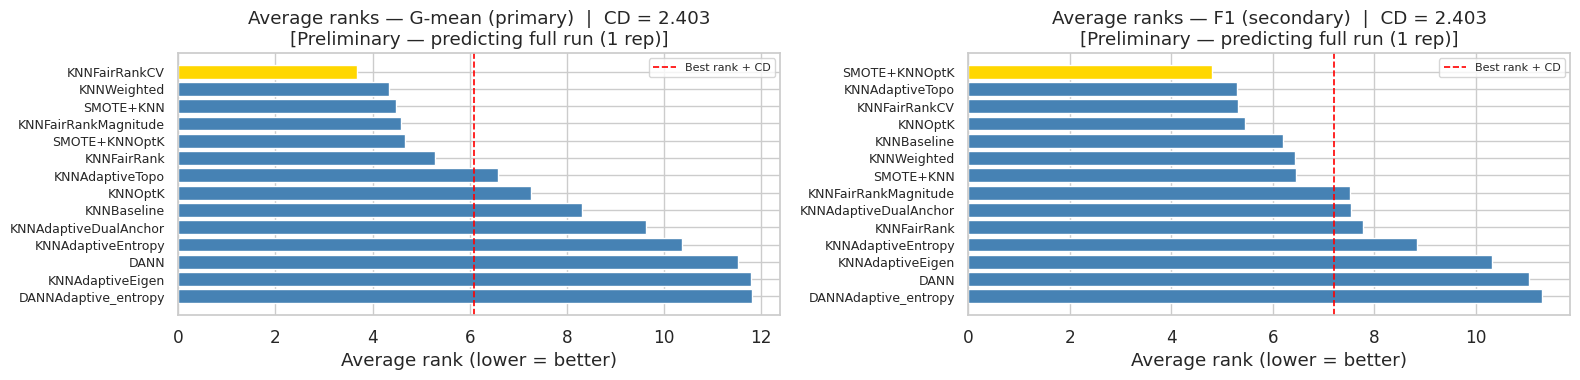

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, metric, label in zip(axes, ["geometric_mean", "f1"], ["G-mean (primary)", "F1 (secondary)"]):
    ranks = average_ranks(bench_df, metric=metric)
    cd    = critical_difference(bench_df, metric=metric)

    print(f"\nAverage ranks ({label}) [{MODE_LABEL}]:")
    print(ranks.round(3).to_string())
    print(f"Critical difference (Nemenyi α=0.05): {cd:.3f}")

    colors_rank = ["gold" if ranks.iloc[i] == ranks.min() else "steelblue" for i in range(len(ranks))]
    ax.barh(range(len(ranks)), ranks.values, color=colors_rank, edgecolor="white")
    ax.set_yticks(range(len(ranks))); ax.set_yticklabels(ranks.index, fontsize=9)
    ax.set_xlabel("Average rank (lower = better)")
    ax.set_title(f"Average ranks — {label}  |  CD = {cd:.3f}\n[{MODE_LABEL}]")
    ax.axvline(ranks.min() + cd, color="red", linestyle="--", linewidth=1.2, label="Best rank + CD")
    ax.legend(fontsize=8); ax.invert_yaxis()

    ranks.round(3).to_frame("avg_rank").to_csv(TAB_DIR / f"average_ranks_{metric}_{FILE_SUFFIX}.csv")

plt.tight_layout()
fig.savefig(FIG_DIR / f"average_ranks_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()